# Does `greedy_merit` Ensemble Actually Need Multiple Models?

**Question:** With `ensemble_agg = greedy_merit`, the ensemble picks the best member per sample.
If the **same** model always wins, we could just use that single model. If **different** models
win for different instances, the ensemble adds value.

**Test:**
1. Load ensemble members individually
2. For each test instance, compute member-level merits *after* post-processing
3. Record which member is best per instance
4. Analyse: is a single model dominant, or does selection vary?

In [1]:
import os, sys, glob, yaml, torch
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

from torch.utils.data import DataLoader
from models.neural_networks import MLP, EnsembleMLP
from utils.trainer import load_instance, create_model, DEVICE
from utils.evaluator import Evaluator
from eval import load_single_model, resolve_checkpoints, load_model_from_checkpoint

print(f"Device: {DEVICE}")

Device: cpu


## 1. Configure — point to your ensemble run directory

In [2]:
# ── EDIT THIS ──
CKPT_PATHS = None

# RUN_DIR = "results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260315-172824_FSNet_seed0_e300_lr1e-04_n7000_ens5_vanilla_pre"    
# RUN_DIR = "results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260315-174003_FSNet_seed100_e300_lr1e-04_n7000_ens5_vanilla_pre"  
RUN_DIR = "results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260316-003057_FSNet_seed2025_e300_lr1e-04_n7000_ens5_vanilla_pre" 

# RUN_DIR = "results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260316-003102_penalty_seed0_e1000_lr1e-04_n7000_ens5_vanilla_pre" 
# RUN_DIR = "results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260316-004753_penalty_seed100_e1000_lr1e-04_n7000_ens5_vanilla_pre" 
# RUN_DIR = "results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260316-010442_penalty_seed2025_e1000_lr1e-04_n7000_ens5_vanilla_pre" 

# OR specify checkpoint paths directly:
# CKPT_PATHS = [
#     "results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260306-050202_FSNet_seed100_e300_lr1e-04_n7000_ens5_vanilla_pre/members/member_0.pt",
#     "results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260306-050202_FSNet_seed100_e300_lr1e-04_n7000_ens5_vanilla_pre/members/member_1.pt",
#     "results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260306-050202_FSNet_seed100_e300_lr1e-04_n7000_ens5_vanilla_pre/members/member_2.pt",
#     "results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260306-050202_FSNet_seed100_e300_lr1e-04_n7000_ens5_vanilla_pre/members/member_3.pt",
#     "results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260306-050202_FSNet_seed100_e300_lr1e-04_n7000_ens5_vanilla_pre/members/member_4.pt",
#     "results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260227-025927_FSNet_seed0_e300_lr1e-04_n7000_ens5_vanilla_pre/members/member_0.pt",
#     "results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260227-025927_FSNet_seed0_e300_lr1e-04_n7000_ens5_vanilla_pre/members/member_1.pt",
#     "results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260227-025927_FSNet_seed0_e300_lr1e-04_n7000_ens5_vanilla_pre/members/member_2.pt",
#     "results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260227-025927_FSNet_seed0_e300_lr1e-04_n7000_ens5_vanilla_pre/members/member_3.pt",
#     "results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260227-025927_FSNet_seed0_e300_lr1e-04_n7000_ens5_vanilla_pre/members/member_4.pt",
#     ]     

BATCH_SIZE = 512
PENALTY = 1e5           # merit = obj + PENALTY * (eq_viol + ineq_viol), matches _aggregate_predictions

# Resolve checkpoint paths
if CKPT_PATHS:
    checkpoints = CKPT_PATHS
elif RUN_DIR:
    checkpoints = resolve_checkpoints(RUN_DIR)
else:
    raise ValueError("Set either RUN_DIR or CKPT_PATHS")

print(f"Found {len(checkpoints)} checkpoint(s):")
for i, c in enumerate(checkpoints):
    print(f"  [{i}] {c}")

Found 5 checkpoint(s):
  [0] results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260316-003057_FSNet_seed2025_e300_lr1e-04_n7000_ens5_vanilla_pre/members/member_0.pt
  [1] results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260316-003057_FSNet_seed2025_e300_lr1e-04_n7000_ens5_vanilla_pre/members/member_1.pt
  [2] results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260316-003057_FSNet_seed2025_e300_lr1e-04_n7000_ens5_vanilla_pre/members/member_2.pt
  [3] results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260316-003057_FSNet_seed2025_e300_lr1e-04_n7000_ens5_vanilla_pre/members/member_3.pt
  [4] results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260316-003057_FSNet_seed2025_e300_lr1e-04_n7000_ens5_vanilla_pre/members/member_4.pt


## 2. Load problem & individual models

In [3]:
# Load config from first checkpoint
first_ckpt = torch.load(checkpoints[0], map_location='cpu', weights_only=False)
config = first_ckpt['config']
config['_eval_only'] = True
config['ensemble_post'] = "post"
config['ensemble_agg'] = 'best_merit'

method = config['method']
print(config)

opt_problem, _ = load_instance(config)
print(f"Test set size: {len(opt_problem.test_dataset)}")

{'seed': 2025, 'train_size': 7000, 'val_size': 1000, 'test_size': 2000, 'batch_size': 512, 'test_batch_sizes': [256, 512], 'eval_step': 10, 'network': 'MLP', 'hidden_dim': 1024, 'num_layers': 4, 'dropout': 0.1, 'MoE': {'num_experts': 4, 'top_k': 2, 'aux_loss_weight': 0.01, 'gate_temperature': 1.0, 'gate_noise_std': 0.0, 'warmup_epochs': 30, 'start_temp': 2.0, 'final_temp': 1.0, 'gate_noise_final': 0.0, 'temp_decay_epochs': 200}, 'penalty': {'lr': 0.0001, 'num_epochs': 1000, 'obj_weight': 1.0, 'eq_pen_weight': 10.0, 'ineq_pen_weight': 10.0, 'dist_weight': 5.0, 'scale': 1000, 'val_tol': 1e-07, 'test_val_tol': 1e-09, 'decay_tol_step': 100, 'memory_size': 30, 'max_iter': 50, 'max_diff_iter': 30}, 'adaptive_penalty': {'lr': 0.0001, 'num_epochs': 1000, 'obj_weight': 1.0, 'eq_pen_weight': 10.0, 'ineq_pen_weight': 10.0, 'dist_weight': 5.0, 'scale': 1000, 'val_tol': 1e-07, 'test_val_tol': 1e-09, 'decay_tol_step': 100, 'memory_size': 30, 'max_iter': 50, 'max_diff_iter': 30, 'eq_pen_weight_max': 

In [4]:
# Load each member individually
members = []
for ckpt_path in checkpoints:
    m, _ = load_single_model(ckpt_path, opt_problem)
    members.append(m)
    print(f"  Loaded member {len(members)-1}: {os.path.basename(ckpt_path)}")

n_members = len(members)
print(f"\nTotal members: {n_members}")

  Loaded member 0: member_0.pt
  Loaded member 1: member_1.pt
  Loaded member 2: member_2.pt
  Loaded member 3: member_3.pt
  Loaded member 4: member_4.pt

Total members: 5


## 3. Evaluate each member's merit per test instance

In [5]:
evaluator = Evaluator(opt_problem, method, config)

test_loader = DataLoader(opt_problem.test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Collect per-member, per-instance merit scores
# Shape will be (n_members, n_test)
all_merits = []  # list of (n_test,) arrays, one per member
all_objs = []
all_eq_viol = []
all_ineq_viol = []
all_opt_gaps = []
obj_true_per_instance = None

for m_idx, member_model in enumerate(members):
    member_merits = []
    member_objs = []
    member_eq = []
    member_ineq = []
    member_opt_gap = []
    member_obj_true = []

    with torch.no_grad():
        for X_batch, Y_true in test_loader:
            X_batch = X_batch.to(DEVICE)
            Y_true = Y_true.to(DEVICE)

            # Get raw NN prediction
            Y_pred = member_model(X_batch)
            Y_scaled = opt_problem.scale(Y_pred)

            # Apply post-processing (L-BFGS etc.) — same as the evaluator does
            with torch.enable_grad():
                Y_final = evaluator._post_process_predictions(X_batch, Y_scaled)

            # Compute per-instance metrics
            obj = opt_problem.obj_fn(Y_final)                      # (B,)
            obj_true = opt_problem.obj_fn(Y_true)                  # (B,)
            eq_l1 = opt_problem.eq_resid(X_batch, Y_final).abs().sum(dim=1)
            ineq_l1 = opt_problem.ineq_resid(X_batch, Y_final).abs().sum(dim=1)
            merit = obj + PENALTY * (eq_l1 + ineq_l1)
            opt_gap = 100.0 * (obj - obj_true) / obj_true.abs().clamp_min(1e-12)

            member_merits.append(merit.cpu())
            member_objs.append(obj.cpu())
            member_eq.append(eq_l1.cpu())
            member_ineq.append(ineq_l1.cpu())
            member_opt_gap.append(opt_gap.cpu())
            if m_idx == 0:
                member_obj_true.append(obj_true.cpu())

    all_merits.append(torch.cat(member_merits).numpy())
    all_objs.append(torch.cat(member_objs).numpy())
    all_eq_viol.append(torch.cat(member_eq).numpy())
    all_ineq_viol.append(torch.cat(member_ineq).numpy())
    all_opt_gaps.append(torch.cat(member_opt_gap).numpy())
    if m_idx == 0:
        obj_true_per_instance = torch.cat(member_obj_true).numpy()
    print(f"  Member {m_idx}: mean_merit={all_merits[-1].mean():.4e}  mean_obj={all_objs[-1].mean():.4e}  mean_opt_gap={all_opt_gaps[-1].mean():.4e}%")

merits = np.stack(all_merits)      # (M, N)
objs = np.stack(all_objs)          # (M, N)
eq_viols = np.stack(all_eq_viol)   # (M, N)
ineq_viols = np.stack(all_ineq_viol)
opt_gaps = np.stack(all_opt_gaps)  # (M, N)

print(f"\nMerits shape: {merits.shape}  (members x test_instances)")

  Member 0: mean_merit=2.2094e+01  mean_obj=1.6475e+01  mean_opt_gap=-5.1387e+00%
  Member 1: mean_merit=3.2115e+01  mean_obj=2.5382e+01  mean_opt_gap=4.6269e+01%
  Member 2: mean_merit=5.2084e+01  mean_obj=2.1611e+01  mean_opt_gap=2.4526e+01%
  Member 3: mean_merit=2.1587e+01  mean_obj=1.7423e+01  mean_opt_gap=1.7901e-01%
  Member 4: mean_merit=2.4060e+01  mean_obj=1.9097e+01  mean_opt_gap=1.0084e+01%

Merits shape: (5, 2000)  (members x test_instances)


## 4. Which member wins per instance?

In [6]:
best_member_per_instance = merits.argmin(axis=0)  # (N,)
n_test = merits.shape[1]

win_counts = Counter(best_member_per_instance.tolist())
print("Win counts per member (how many instances each member is best):")
for m_idx in range(n_members):
    count = win_counts.get(m_idx, 0)
    pct = 100 * count / n_test
    print(f"  Member {m_idx}: {count:5d} / {n_test}  ({pct:.1f}%)")

# Is it dominated by one model?
most_common_member, most_common_count = win_counts.most_common(1)[0]
dominance_pct = 100 * most_common_count / n_test
print(f"\n{'='*50}")
print(f"Most dominant member: {most_common_member}  ({dominance_pct:.1f}% of instances)")

Win counts per member (how many instances each member is best):
  Member 0:   600 / 2000  (30.0%)
  Member 1:     0 / 2000  (0.0%)
  Member 2:     8 / 2000  (0.4%)
  Member 3:  1321 / 2000  (66.0%)
  Member 4:    71 / 2000  (3.5%)

Most dominant member: 3  (66.0% of instances)


## 5. Visualizations

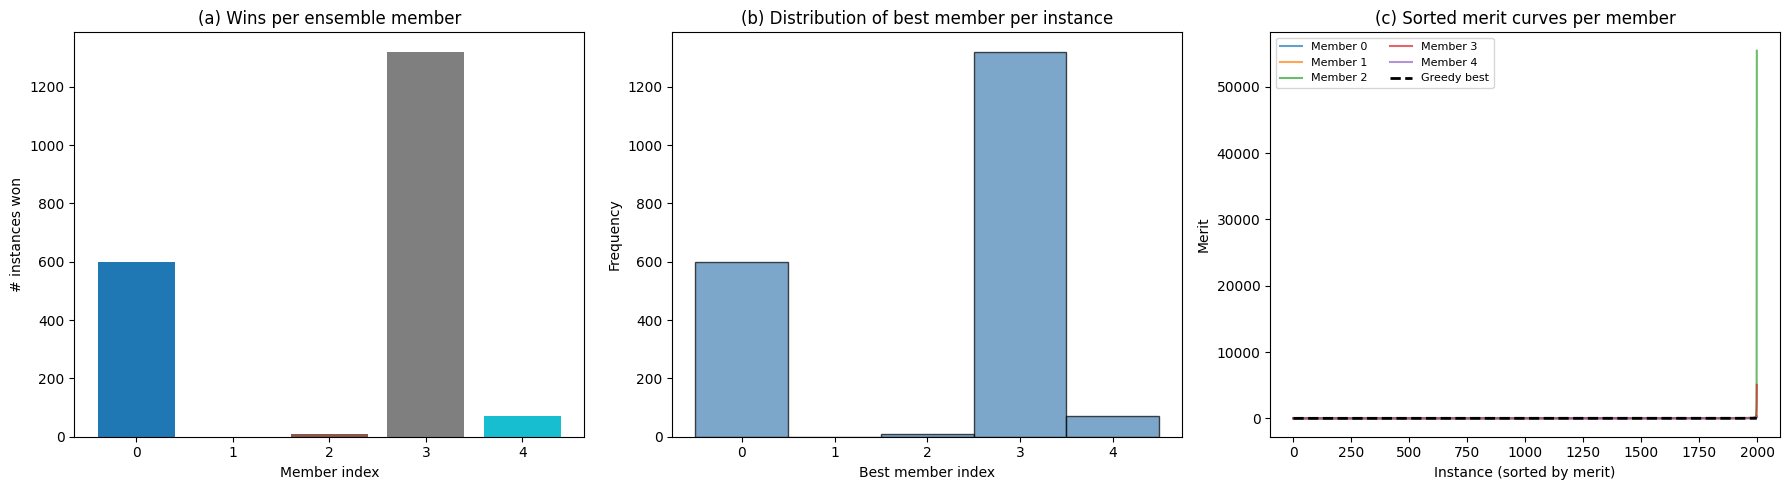

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- (a) Bar chart: wins per member ---
ax = axes[0]
member_ids = list(range(n_members))
counts = [win_counts.get(i, 0) for i in member_ids]
colors = plt.cm.tab10(np.linspace(0, 1, n_members))
ax.bar(member_ids, counts, color=colors)
ax.set_xlabel('Member index')
ax.set_ylabel('# instances won')
ax.set_title('(a) Wins per ensemble member')
ax.set_xticks(member_ids)

# --- (b) Histogram of best-member index across instances ---
ax = axes[1]
ax.hist(best_member_per_instance, bins=np.arange(-0.5, n_members + 0.5, 1),
        edgecolor='black', alpha=0.7, color='steelblue')
ax.set_xlabel('Best member index')
ax.set_ylabel('Frequency')
ax.set_title('(b) Distribution of best member per instance')
ax.set_xticks(member_ids)

# --- (c) Sorted merit per member to show overlap ---
ax = axes[2]
for m_idx in range(n_members):
    sorted_m = np.sort(merits[m_idx])
    ax.plot(sorted_m, label=f'Member {m_idx}', alpha=0.7)
# Also show the greedy-best merit
greedy_best = merits.min(axis=0)
ax.plot(np.sort(greedy_best), 'k--', linewidth=2, label='Greedy best')
ax.set_xlabel('Instance (sorted by merit)')
ax.set_ylabel('Merit')
ax.set_title('(c) Sorted merit curves per member')
ax.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

In [8]:
# --- Improvement from ensemble over single-best-overall model ---
mean_merits_per_member = merits.mean(axis=1)  # (M,)
overall_best_member = most_common_member 
# overall_best_member = mean_merits_per_member.argmin()
print(f"Overall best single member (by mean merit): Member {overall_best_member}")
print(f"  Mean merit: {mean_merits_per_member[overall_best_member]:.4e}")

best_merit_per_instance = merits.min(axis=0)  # (N,)
greedy_mean = best_merit_per_instance.mean()
single_mean = mean_merits_per_member[overall_best_member]

improvement_abs = single_mean - greedy_mean
improvement_pct = 100 * improvement_abs / single_mean

print(f"\nGreedy-ensemble mean merit: {greedy_mean:.4e}")
print(f"Single-best mean merit:     {single_mean:.4e}")
print(f"Improvement:  {improvement_abs:.4e}  ({improvement_pct:.2f}%)")

Overall best single member (by mean merit): Member 3
  Mean merit: 2.1587e+01

Greedy-ensemble mean merit: 1.7538e+01
Single-best mean merit:     2.1587e+01
Improvement:  4.0490e+00  (18.76%)


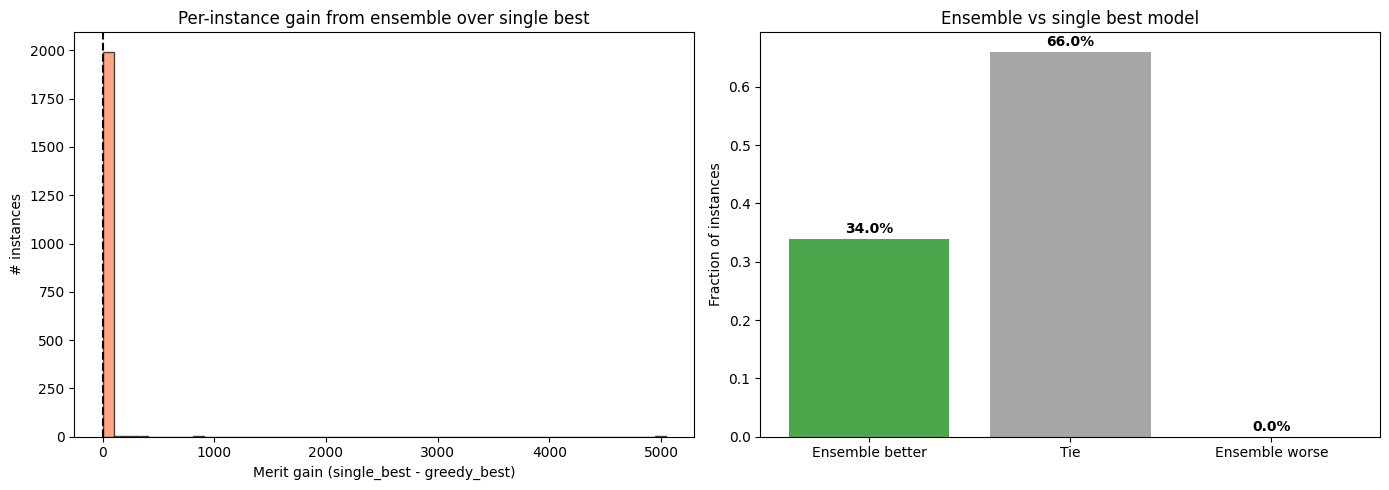

In [9]:
# --- Per-instance: how much does the greedy winner beat the single best model? ---
single_merits = merits[overall_best_member]  # (N,)
per_instance_gain = single_merits - best_merit_per_instance  # (N,)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(per_instance_gain, bins=50, edgecolor='black', alpha=0.7, color='coral')
ax.axvline(0, color='k', linestyle='--')
ax.set_xlabel('Merit gain (single_best - greedy_best)')
ax.set_ylabel('# instances')
ax.set_title('Per-instance gain from ensemble over single best')

ax = axes[1]
frac_improved = (per_instance_gain > 0).mean()
frac_same = (per_instance_gain == 0).mean()
frac_worse = (per_instance_gain < 0).mean()
ax.bar(['Ensemble better', 'Tie', 'Ensemble worse'],
       [frac_improved, frac_same, frac_worse],
       color=['green', 'gray', 'red'], alpha=0.7)
ax.set_ylabel('Fraction of instances')
ax.set_title('Ensemble vs single best model')
for i, v in enumerate([frac_improved, frac_same, frac_worse]):
    ax.text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [10]:
# --- Summary table ---
greedy_obj_per_instance = objs[best_member_per_instance, np.arange(n_test)]
greedy_opt_gap_per_instance = 100.0 * (greedy_obj_per_instance - obj_true_per_instance) / np.maximum(np.abs(obj_true_per_instance), 1e-12)
greedy_opt_gap_mean = greedy_opt_gap_per_instance.mean()
single_opt_gap_mean = opt_gaps[overall_best_member].mean()

print(f"{'Member':10} {'Mean Merit':14} {'Mean Obj':14} {'Mean Eq Viol':14} {'Mean Ineq Viol':14} {'Mean OptGap(%)':16} {'Wins':8}")
print('-' * 110)
for m_idx in range(n_members):
    print(f"{m_idx:10} {merits[m_idx].mean():14.2e} {objs[m_idx].mean():14.2e} "
          f"{eq_viols[m_idx].mean():14.2e} {ineq_viols[m_idx].mean():14.2e} "
          f"{opt_gaps[m_idx].mean():16.2e} {win_counts.get(m_idx, 0):8}")
print('-' * 110)
print(f"{'Greedy':10} {greedy_mean:14.2e} {'-':14} {'-':14} {'-':14} {greedy_opt_gap_mean:16.2e}")
print(f"{'Best-1':10} {single_mean:14.2e} {'-':14} {'-':14} {'-':14} {single_opt_gap_mean:16.2e}  (Member {overall_best_member})")

Member     Mean Merit     Mean Obj       Mean Eq Viol   Mean Ineq Viol Mean OptGap(%)   Wins    
--------------------------------------------------------------------------------------------------------------
         0       2.21e+01       1.65e+01       5.58e-05       4.23e-07        -5.14e+00      600
         1       3.21e+01       2.54e+01       6.69e-05       4.53e-07         4.63e+01        0
         2       5.21e+01       2.16e+01       2.64e-04       4.10e-05         2.45e+01        8
         3       2.16e+01       1.74e+01       3.80e-05       3.60e-06         1.79e-01     1321
         4       2.41e+01       1.91e+01       4.93e-05       2.87e-07         1.01e+01       71
--------------------------------------------------------------------------------------------------------------
Greedy           1.75e+01 -              -              -                     -2.50e+00
Best-1           2.16e+01 -              -              -                      1.79e-01  (Member 3)


In [11]:
# ── Deep-dive: how bad is Member Best on the instances it loses? ──
import numpy as np

dominant = overall_best_member
loses_mask = best_member_per_instance != dominant  # instances where Member Best is NOT best
wins_mask = best_member_per_instance == dominant

n_loses = loses_mask.sum()
n_wins = wins_mask.sum()

print(f"Member {dominant} loses on {n_loses} / {len(best_member_per_instance)} instances\n")

# Merit of Member Best vs greedy-best on instances where Member Best loses
member3_merit_on_losses = merits[dominant][loses_mask]
best_merit_on_losses  = np.array([merits[best_member_per_instance[i]][i] 
                                     for i in np.where(loses_mask)[0]])

gap_on_losses = member3_merit_on_losses - best_merit_on_losses

print("On instances where Member Best loses:")
print(f"  Member Best mean merit:      {member3_merit_on_losses.mean():.4e}")
print(f"  Best-member mean merit:   {best_merit_on_losses.mean():.4e}")
print(f"  Mean gap (M3 - best):     {gap_on_losses.mean():.4e}")
print(f"  Max gap:                  {gap_on_losses.max():.4e}")
print(f"  Min gap:                  {gap_on_losses.min():.4e}")
print(f"  Median gap:               {np.median(gap_on_losses):.4e}")

print(f"\nOn instances where Member Best wins:")
member3_merit_on_wins = merits[dominant][wins_mask]
second_best_on_wins = np.array([
    np.partition([merits[m][i] for m in range(len(merits)) if m != dominant], 0)[0]
    for i in np.where(wins_mask)[0]
])
margin_on_wins = second_best_on_wins - member3_merit_on_wins
print(f"  Member Best mean merit:      {member3_merit_on_wins.mean():.4e}")
print(f"  2nd-best mean merit:      {second_best_on_wins.mean():.4e}")
print(f"  Mean margin (2nd - M3):   {margin_on_wins.mean():.4e}")

print(f"\n{'='*60}")
print(f"Contribution breakdown to overall mean merit improvement:")
total_improvement = merits[dominant].mean() - np.array([
    merits[best_member_per_instance[i]][i] for i in range(len(best_member_per_instance))
]).mean()
improvement_from_losses = (member3_merit_on_losses.sum() - best_merit_on_losses.sum()) / len(best_member_per_instance)
improvement_from_wins = 0.0  # no improvement on wins (Member Best IS the best)

print(f"  Total improvement:           {total_improvement:.4e}")
print(f"  From loss instances ({n_loses:4d}):  {improvement_from_losses:.4e}  ({improvement_from_losses/total_improvement*100:.1f}%)")
print(f"  From win instances  ({n_wins:4d}):  {improvement_from_wins:.4e}  ({improvement_from_wins/total_improvement*100:.1f}%)")

Member 3 loses on 679 / 2000 instances

On instances where Member Best loses:
  Member Best mean merit:      2.9361e+01
  Best-member mean merit:   1.7434e+01
  Mean gap (M3 - best):     1.1927e+01
  Max gap:                  5.0426e+03
  Min gap:                  1.0956e-03
  Median gap:               8.2304e-01

On instances where Member Best wins:
  Member Best mean merit:      1.7592e+01
  2nd-best mean merit:      1.9616e+01
  Mean margin (2nd - M3):   2.0247e+00

Contribution breakdown to overall mean merit improvement:
  Total improvement:           4.0490e+00
  From loss instances ( 679):  4.0490e+00  (100.0%)
  From win instances  (1321):  0.0000e+00  (0.0%)


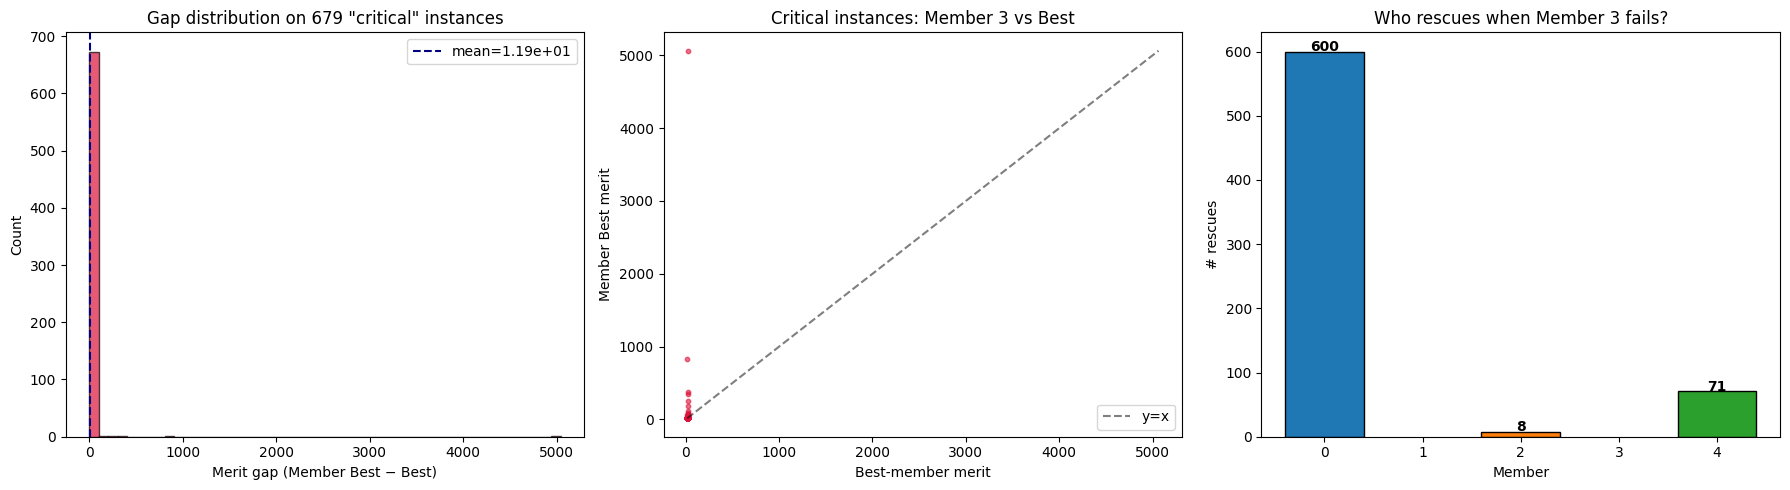


Rescue breakdown:
  Member 0: rescues 600 instances (88.4%)
  Member 2: rescues 8 instances (1.2%)
  Member 4: rescues 71 instances (10.5%)


In [12]:
# Add as another new cell — visualize the "critical" instances

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Histogram of gaps on loss instances
axes[0].hist(gap_on_losses, bins=50, edgecolor='k', alpha=0.7, color='crimson')
axes[0].set_xlabel('Merit gap (Member Best − Best)')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Gap distribution on {n_loses} "critical" instances')
axes[0].axvline(gap_on_losses.mean(), color='navy', ls='--', label=f'mean={gap_on_losses.mean():.2e}')
axes[0].legend()

# 2) Scatter: Member Best merit vs best-member merit on loss instances
axes[1].scatter(best_merit_on_losses, member3_merit_on_losses, s=10, alpha=0.6, c='crimson')
lims = [min(best_merit_on_losses.min(), member3_merit_on_losses.min()),
        max(best_merit_on_losses.max(), member3_merit_on_losses.max())]
axes[1].plot(lims, lims, 'k--', alpha=0.5, label='y=x')
axes[1].set_xlabel('Best-member merit')
axes[1].set_ylabel('Member Best merit')
axes[1].set_title('Critical instances: Member 3 vs Best')
axes[1].legend()

# 3) Which members rescue these instances?
rescue_members = best_member_per_instance[loses_mask]
unique, counts = np.unique(rescue_members, return_counts=True)
axes[2].bar(unique, counts, color=['C0','C1','C2','C3','C4'], edgecolor='k')
axes[2].set_xlabel('Member')
axes[2].set_ylabel('# rescues')
axes[2].set_title('Who rescues when Member 3 fails?')
for u, c in zip(unique, counts):
    axes[2].text(u, c + 0.5, str(c), ha='center', fontweight='bold')

plt.tight_layout()
# plt.savefig('critical_instances_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nRescue breakdown:")
for u, c in zip(unique, counts):
    print(f"  Member {u}: rescues {c} instances ({c/n_loses*100:.1f}%)")

In [13]:
# ── What's special about instances where Member 3 fails? ──

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

dominant = 3
loses_mask = best_member_per_instance != dominant
wins_mask = best_member_per_instance == dominant

# Get the raw input features (X) for all test instances
X_all = []
Y_all = []
for X_batch, Y_batch in test_loader:
    X_all.append(X_batch.numpy())
    Y_all.append(Y_batch.numpy())
X_all = np.concatenate(X_all, axis=0)  # (N, d_in)
Y_all = np.concatenate(Y_all, axis=0)  # (N, d_out)

X_fail = X_all[loses_mask]
X_win  = X_all[wins_mask]
Y_fail = Y_all[loses_mask]
Y_win  = Y_all[wins_mask]

n_fail = X_fail.shape[0]
n_win  = X_win.shape[0]
d_in   = X_all.shape[1]

print(f"Feature dim: {d_in}")
print(f"Fail instances: {n_fail},  Win instances: {n_win}\n")

# ── 1. Basic feature statistics: mean, std, norms ──
print("="*70)
print("Feature-level comparison (mean ± std)")
print(f"{'Statistic':30} {'Fail instances':22} {'Win instances':22} {'p-value':12}")
print("-"*86)

# Norms
fail_norms = np.linalg.norm(X_fail, axis=1)
win_norms  = np.linalg.norm(X_win, axis=1)
_, p_norm = stats.mannwhitneyu(fail_norms, win_norms, alternative='two-sided')
print(f"{'||x||_2 (input norm)':30} {fail_norms.mean():.4f} ± {fail_norms.std():.4f}    "
      f"{win_norms.mean():.4f} ± {win_norms.std():.4f}    {p_norm:.2e}")

# Per-feature mean
fail_feat_mean = X_fail.mean(axis=1)
win_feat_mean  = X_win.mean(axis=1)
_, p_fmean = stats.mannwhitneyu(fail_feat_mean, win_feat_mean, alternative='two-sided')
print(f"{'mean(x_i) per instance':30} {fail_feat_mean.mean():.4f} ± {fail_feat_mean.std():.4f}    "
      f"{win_feat_mean.mean():.4f} ± {win_feat_mean.std():.4f}    {p_fmean:.2e}")

# Per-feature std (spread within each instance)
fail_feat_std = X_fail.std(axis=1)
win_feat_std  = X_win.std(axis=1)
_, p_fstd = stats.mannwhitneyu(fail_feat_std, win_feat_std, alternative='two-sided')
print(f"{'std(x_i) per instance':30} {fail_feat_std.mean():.4f} ± {fail_feat_std.std():.4f}    "
      f"{win_feat_std.mean():.4f} ± {win_feat_std.std():.4f}    {p_fstd:.2e}")

# Min / Max feature
fail_feat_min = X_fail.min(axis=1)
win_feat_min  = X_win.min(axis=1)
_, p_fmin = stats.mannwhitneyu(fail_feat_min, win_feat_min, alternative='two-sided')
print(f"{'min(x_i) per instance':30} {fail_feat_min.mean():.4f} ± {fail_feat_min.std():.4f}    "
      f"{win_feat_min.mean():.4f} ± {win_feat_min.std():.4f}    {p_fmin:.2e}")

fail_feat_max = X_fail.max(axis=1)
win_feat_max  = X_win.max(axis=1)
_, p_fmax = stats.mannwhitneyu(fail_feat_max, win_feat_max, alternative='two-sided')
print(f"{'max(x_i) per instance':30} {fail_feat_max.mean():.4f} ± {fail_feat_max.std():.4f}    "
      f"{win_feat_max.mean():.4f} ± {win_feat_max.std():.4f}    {p_fmax:.2e}")

# Solution norms
fail_sol_norms = np.linalg.norm(Y_fail, axis=1)
win_sol_norms  = np.linalg.norm(Y_win, axis=1)
_, p_snorm = stats.mannwhitneyu(fail_sol_norms, win_sol_norms, alternative='two-sided')
print(f"{'||y*||_2 (solution norm)':30} {fail_sol_norms.mean():.4f} ± {fail_sol_norms.std():.4f}    "
      f"{win_sol_norms.mean():.4f} ± {win_sol_norms.std():.4f}    {p_snorm:.2e}")

print("-"*86)
print("(p < 0.05 → statistically significant difference)\n")

Feature dim: 50
Fail instances: 679,  Win instances: 1321

Feature-level comparison (mean ± std)
Statistic                      Fail instances         Win instances          p-value     
--------------------------------------------------------------------------------------
||x||_2 (input norm)           4.0641 ± 0.2524    4.0763 ± 0.2609    3.99e-01
mean(x_i) per instance         -0.0020 ± 0.0769    -0.0002 ± 0.0806    7.45e-01
std(x_i) per instance          0.5696 ± 0.0361    0.5708 ± 0.0375    5.46e-01
min(x_i) per instance          -0.9600 ± 0.0385    -0.9594 ± 0.0416    7.19e-01
max(x_i) per instance          0.9598 ± 0.0415    0.9601 ± 0.0388    6.58e-01
||y*||_2 (solution norm)       12.8376 ± 0.5226    12.7978 ± 0.5060    4.26e-02
--------------------------------------------------------------------------------------
(p < 0.05 → statistically significant difference)



In [14]:
# ── 4. Top-10 worst failures: examine individual instances ──

# Rank fail instances by gap (M3 merit - best merit)
fail_indices = np.where(loses_mask)[0]
gap_sorted_idx = np.argsort(gap_on_losses)[::-1]  # largest gap first

print("Top 10 instances where Member Best fails the worst:")
print(f"{'Rank':6} {'Inst idx':10} {'M3 merit':14} {'Best merit':14} {'Gap':14} "
      f"{'Best member':12} {'||x||₂':10} {'||y*||₂':10}")
print("-"*90)

worst_10_indices = []
for rank, loc in enumerate(gap_sorted_idx[:10]):
    i = fail_indices[loc]
    m3_m = merits[dominant][i]
    best_m = merits[best_member_per_instance[i]][i]
    gap = m3_m - best_m
    bm = best_member_per_instance[i]
    xn = np.linalg.norm(X_all[i])
    yn = np.linalg.norm(Y_all[i])
    worst_10_indices.append(i)
    print(f"{rank+1:6} {i:10} {m3_m:14.4e} {best_m:14.4e} {gap:14.4e} "
          f"{bm:12} {xn:10.4f} {yn:10.4f}")

print("\nBreakdown of all member merits on top-5 worst instances:")
for rank, i in enumerate(worst_10_indices[:5]):
    print(f"\n  Instance {i} (rank {rank+1}):")
    for m_idx in range(n_members):
        marker = " *** BEST" if m_idx == best_member_per_instance[i] else ""
        marker2 = " (dominant)" if m_idx == dominant else ""
        print(f"    Member {m_idx}: merit={merits[m_idx][i]:.4e}  "
              f"obj={objs[m_idx][i]:.4e}  eq_viol={eq_viols[m_idx][i]:.4e}  "
              f"ineq_viol={ineq_viols[m_idx][i]:.4e}{marker}{marker2}")

Top 10 instances where Member Best fails the worst:
Rank   Inst idx   M3 merit       Best merit     Gap            Best member  ||x||₂     ||y*||₂   
------------------------------------------------------------------------------------------
     1        464     5.0639e+03     2.1388e+01     5.0426e+03            4     4.2621    12.6988
     2        208     8.2766e+02     1.7945e+01     8.0971e+02            0     4.3759    13.2821
     3       1639     3.7716e+02     2.0587e+01     3.5658e+02            2     4.1397    13.4750
     4        964     3.4284e+02     2.2466e+01     3.2038e+02            0     4.3916    12.5859
     5       1308     2.5346e+02     2.4146e+01     2.2931e+02            2     4.3745    13.6496
     6       1137     1.8878e+02     2.2681e+01     1.6610e+02            2     4.2469    12.6300
     7       1134     1.2004e+02     2.1873e+01     9.8162e+01            2     4.5359    12.8766
     8       1380     8.5606e+01     1.9705e+01     6.5901e+01           

In [15]:
# Replace the "Improvement from ensemble over single-best-overall model" cell with this:

# --- Improvement from ensemble over K-best-overall model ---
# Instead of comparing against just the single best member, compare against
# the top-K members (a smaller sub-ensemble that always uses greedy_merit among K members).

mean_merits_per_member = merits.mean(axis=1)  # (M,)
member_rank = np.argsort(mean_merits_per_member)  # ascending (best first)

best_merit_per_instance = merits.min(axis=0)  # (N,) — full ensemble greedy
greedy_mean = best_merit_per_instance.mean()

print(f"Full ensemble ({n_members} members) greedy mean merit: {greedy_mean:.4e}\n")
print(f"{'K':5} {'Top-K members':40} {'Top-K greedy mean':20} {'vs Full ens':16} {'vs K=1':16}")
print("="*97)

topk_results = {}
for K in range(1, n_members + 1):
    top_k_members = member_rank[:K]
    # Greedy-best among top-K members only
    topk_merits = merits[top_k_members]  # (K, N)
    topk_greedy = topk_merits.min(axis=0)  # (N,)
    topk_mean = topk_greedy.mean()
    
    # Improvement of full ensemble over this K-subset
    imp_vs_full = topk_mean - greedy_mean
    imp_vs_full_pct = 100 * imp_vs_full / abs(topk_mean) if topk_mean != 0 else 0
    
    # Improvement of this K-subset over K=1
    if K == 1:
        single_mean = topk_mean
        imp_vs_k1 = 0.0
        imp_vs_k1_pct = 0.0
    else:
        imp_vs_k1 = single_mean - topk_mean
        imp_vs_k1_pct = 100 * imp_vs_k1 / abs(single_mean) if single_mean != 0 else 0
    
    members_str = str(top_k_members.tolist())
    print(f"{K:5} {members_str:40} {topk_mean:20.4e} {imp_vs_full:+.4e}     {imp_vs_k1:+.4e}")
    
    topk_results[K] = {
        'members': top_k_members.tolist(),
        'mean_merit': topk_mean,
        'per_instance': topk_greedy,
    }

# ── Find the "elbow": smallest K that captures most of the improvement ──
full_improvement = single_mean - greedy_mean  # total gain from K=1 → K=all
print(f"\n{'='*97}")
print(f"Total improvement (K=1 → K={n_members}): {full_improvement:.4e}")
print(f"\nCumulative improvement captured:")
for K in range(1, n_members + 1):
    captured = single_mean - topk_results[K]['mean_merit']
    pct = 100 * captured / full_improvement if full_improvement != 0 else 0
    bar = '█' * int(pct / 2)
    print(f"  K={K:3}  {captured:+.4e}  ({pct:6.1f}%)  {bar}")

# ── Marginal gain of each additional member ──
print(f"\nMarginal gain from adding each member:")
print(f"{'Step':20} {'Added member':15} {'Marginal gain':18} {'New mean merit':18}")
print("-"*71)
for K in range(2, n_members + 1):
    prev_mean = topk_results[K-1]['mean_merit']
    curr_mean = topk_results[K]['mean_merit']
    marginal = prev_mean - curr_mean
    added = set(topk_results[K]['members']) - set(topk_results[K-1]['members'])
    print(f"K={K-1} → K={K:12} {str(added):15} {marginal:+.4e}        {curr_mean:.4e}")

Full ensemble (5 members) greedy mean merit: 1.7538e+01

K     Top-K members                            Top-K greedy mean    vs Full ens      vs K=1          
    1 [3]                                                2.1587e+01 +4.0490e+00     +0.0000e+00
    2 [3, 0]                                             1.7717e+01 +1.7910e-01     +3.8699e+00
    3 [3, 0, 4]                                          1.7545e+01 +6.8820e-03     +4.0422e+00
    4 [3, 0, 4, 1]                                       1.7545e+01 +6.5157e-03     +4.0425e+00
    5 [3, 0, 4, 1, 2]                                    1.7538e+01 +0.0000e+00     +4.0490e+00

Total improvement (K=1 → K=5): 4.0490e+00

Cumulative improvement captured:
  K=  1  +0.0000e+00  (   0.0%)  
  K=  2  +3.8699e+00  (  95.6%)  ███████████████████████████████████████████████
  K=  3  +4.0422e+00  (  99.8%)  █████████████████████████████████████████████████
  K=  4  +4.0425e+00  (  99.8%)  █████████████████████████████████████████████████
  K

In [16]:
# --- Compare K-member ensemble vs full 10-member ensemble ---

subset_indices = [2, 8]
subset_merits = merits[subset_indices]          # (2, N)
subset_greedy = subset_merits.min(axis=0)       # (N,) — per-instance best among {2, 8}
subset_mean   = subset_greedy.mean()

full_greedy   = merits.min(axis=0)              # (N,) — per-instance best among all 10
full_mean     = full_greedy.mean()

print(f"{'Ensemble':30} {'Mean Merit':16}")
print("=" * 46)
print(f"{'Members {2, 8} (K=2)':30} {subset_mean:16.4e}")
print(f"{'Full ensemble (K=10)':30} {full_mean:16.4e}")

gap = subset_mean - full_mean
gap_pct = 100 * gap / abs(full_mean) if full_mean != 0 else 0
print(f"\nDifference (2-member − full): {gap:+.4e}  ({gap_pct:+.2f}%)")

# Per-instance breakdown
per_inst_diff = subset_greedy - full_greedy  # ≥0 everywhere (full can only be ≤ subset)
frac_same    = (per_inst_diff == 0).mean()
frac_worse   = (per_inst_diff > 0).mean()

print(f"\nPer-instance comparison (N={n_test}):")
print(f"  Same result:       {frac_same:.1%}  ({int(frac_same * n_test)} instances)")
print(f"  Full ens. better:  {frac_worse:.1%}  ({int(frac_worse * n_test)} instances)")
print(f"  Mean extra gap when full is better: "
      f"{per_inst_diff[per_inst_diff > 0].mean():.4e}" if frac_worse > 0 else "  N/A")

# Win counts within the 2-member subset
subset_best = subset_merits.argmin(axis=0)  # 0 or 1 → maps to member 2 or 8
from collections import Counter
sub_wins = Counter(np.array(subset_indices)[subset_best].tolist())
print(f"\nWin distribution within {{2, 8}}:")
for m in subset_indices:
    print(f"  Member {m}: {sub_wins.get(m, 0):5d} / {n_test}  ({100 * sub_wins.get(m, 0) / n_test:.1f}%)")

# Also show individual member stats for context
print(f"\nIndividual member mean merits:")
for m in subset_indices:
    print(f"  Member {m}: {merits[m].mean():.4e}")
print(f"  Best single (Member {overall_best_member}): {mean_merits_per_member[overall_best_member]:.4e}")

IndexError: index 8 is out of bounds for axis 0 with size 5